# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [94]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

Enu_e_had   = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG         = "rec/mc/mc.nu/mc.nu.pdg"

caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]

reco_pfp_tree = uproot.open("reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data = pl.concat([caf_df, reco_pfp_df], how="horizontal")

data = data.filter(pl.col("reco_ok") == True)


data = data.with_columns(
	(1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
	(1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()
data

,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,0.564708,0.018015,1
1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,0.519653,0.689843,1
2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,0.735094,0.745076,1
3,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,0.823313,0.850355,0
4,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,0.988919,0.988908,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,1.000000,1.000000,0
2651023,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,0.984981,0.990219,0
2651024,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,0.887005,0.932367,0
2651025,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,0.959213,0.086923,0


In [95]:
import pandas as pd

consistency = pd.crosstab(data['PDG'] < 0, data['label'])
consistency.index = ['PDG > 0 (Nu)', 'PDG < 0 (Anti-Nu)']
consistency.columns = ['Label 0', 'Label 1']
print(consistency)

                   Label 0  Label 1
PDG > 0 (Nu)       1981454        0
PDG < 0 (Anti-Nu)        0   669573


In [176]:
electron_mask = data['PDG'].abs() == 12
muon_mask = data['PDG'].abs() == 14
tau_mask = data['PDG'].abs() == 16


electron_data = data[electron_mask]
muon_data = data[muon_mask] 
tau_data = data[tau_mask]


In [177]:

feature_columns = [ 'inelasticity_e', 'inelasticity_mu','n_reco_pfps', 'n_reco_tracks', 'n_reco_showers', 'single_hits_energy', 'n_reco_muons_pions', 'n_reco_protons']

X_data = electron_data[feature_columns].values

# believe this labels neutrinos as 0 and anti-neutrinos as 1? 
y_data = electron_data['label']

In [178]:
print(np.unique(y_data, return_counts=True))


(array([0, 1]), array([889751, 283092]))


In [179]:

# # plt.rcParams['agg.path.chunksize'] = 10000
# plt.plot(data['inelasticity_e'], data['PDG'])
# plt.show()


In [180]:
# plt.plot(data['inelasticity_mu'], data['PDG'])

In [181]:
from sklearn.model_selection import train_test_split

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [182]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(
	learning_rate=0.05,
	max_depth=3,
	min_samples_leaf=200,
	max_iter=2000,
	class_weight="balanced",
	early_stopping=True,
	validation_fraction=0.2,
	n_iter_no_change=30,
	random_state=0
).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [183]:

# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

In [184]:
n_index = 0 
an_index = 1

print(np.unique(y_test, return_counts=True))



(array([0, 1]), array([293508,  93531]))


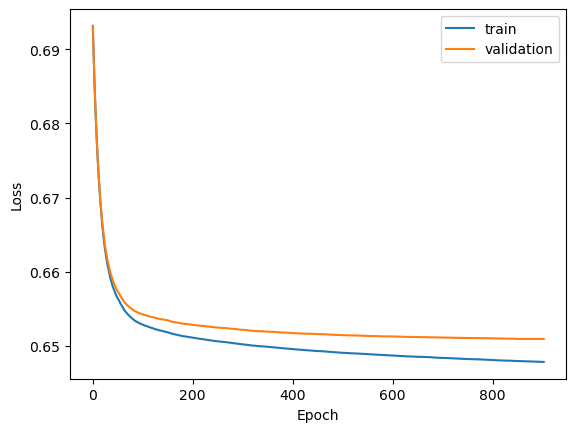

In [185]:
train_loss = [-s for s in clf.train_score_]
val_loss   = [-s for s in clf.validation_score_]

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


(array([3.3000e+01, 2.8000e+01, 2.3000e+01, 1.8700e+02, 2.3300e+02,
        1.8400e+02, 1.7300e+02, 2.1100e+02, 3.1500e+02, 3.1400e+02,
        2.6200e+02, 3.3500e+02, 4.2800e+02, 7.5600e+02, 6.9400e+02,
        1.1170e+03, 1.3290e+03, 1.4100e+03, 1.8610e+03, 2.3640e+03,
        3.1500e+03, 3.8880e+03, 3.9200e+03, 4.4260e+03, 5.4360e+03,
        6.7120e+03, 8.2660e+03, 1.0478e+04, 1.2955e+04, 1.6694e+04,
        1.9377e+04, 1.9175e+04, 1.7715e+04, 1.7677e+04, 1.6450e+04,
        2.9272e+04, 3.4381e+04, 2.1528e+04, 1.2544e+04, 5.3300e+03,
        4.0780e+03, 2.6880e+03, 1.9820e+03, 1.1180e+03, 6.6400e+02,
        4.1700e+02, 3.6200e+02, 4.4500e+02, 1.1000e+02, 1.3000e+01]),
 array([-3.9689847 , -3.85172298, -3.73446127, -3.61719955, -3.49993783,
        -3.38267611, -3.2654144 , -3.14815268, -3.03089096, -2.91362925,
        -2.79636753, -2.67910581, -2.56184409, -2.44458238, -2.32732066,
        -2.21005894, -2.09279723, -1.97553551, -1.85827379, -1.74101207,
        -1.62375036, -1.50

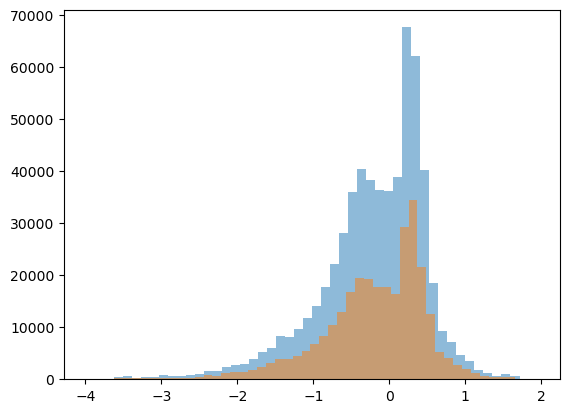

In [186]:
plt.hist(clf.decision_function(X_train[y_train==0]), bins=50, alpha=0.5)
plt.hist(clf.decision_function(X_test[y_test==0]), bins=50, alpha=0.5)


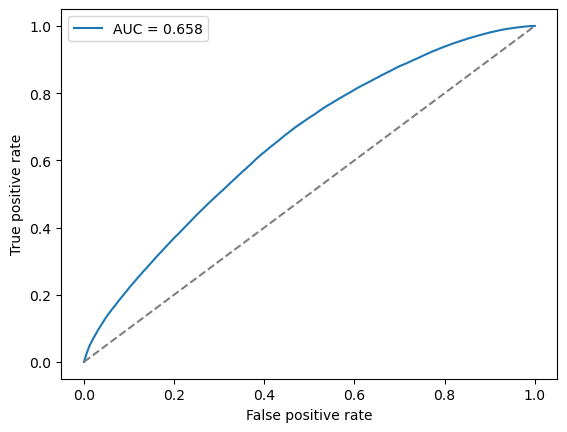

In [187]:
from sklearn.metrics import roc_curve, auc

probs = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()


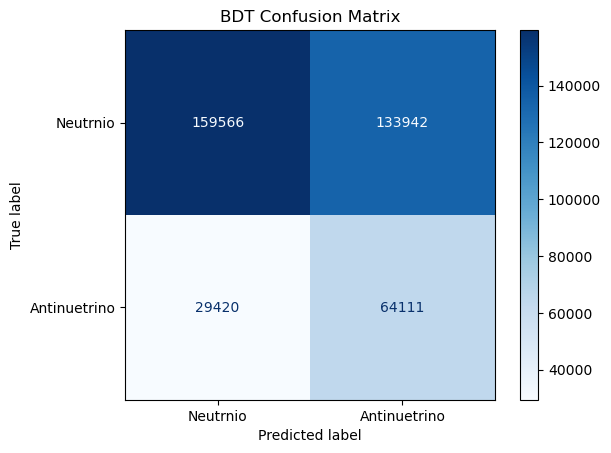

In [188]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()